# Procesamiento Digital de Imágenes
## Guía de Trabajos Prácticos 4 — Procesamiento de Color
**FICH, UNL — Ingeniería Informática**

| Ejercicio | Contenido |
|---|---|
| **Ej 1** | Modelos de color y análisis (RGB, HSV, complementarios, perfiles) |
| **Ej 2** | Pseudocolor sobre imagen de radar/infrarrojo (`rio.jpg`) |
| **Ej 3** | Ecualización y realce en RGB, HSV y HSI |
| **Ej 4** | Segmentación por color: esfera RGB vs subespacio HSV |
| **Ej 5** | Aplicaciones: segmentador interactivo y deforestación satelital |

In [1]:
# Imports globales
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, IntRangeSlider
from IPython.display import display, clear_output
import ipywidgets as widgets

def mostrar(imagenes, titulos, figsize=(16, 5)):
    """Muestra múltiples imágenes en una fila, convirtiendo BGR→RGB automáticamente."""
    n = len(imagenes)
    fig, axs = plt.subplots(1, n, figsize=figsize)
    if n == 1: axs = [axs]
    for ax, img, titulo in zip(axs, imagenes, titulos):
        disp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img
        ax.imshow(disp, cmap='gray' if img.ndim == 2 else None, vmin=0, vmax=255)
        ax.set_title(titulo, fontsize=10); ax.axis('off')
    plt.tight_layout(); plt.show()

def canal_I_hsi(img_bgr):
    """I = (B + G + R) / 3  — canal de intensidad del modelo HSI."""
    return (img_bgr.astype(np.float32).sum(axis=2) / 3).astype(np.uint8)

print('Librerías cargadas.')

Librerías cargadas.


---
## Ejercicio 1: Modelos de color y análisis

Se trabaja con `patron.tif` (degradado de rojo a azul por columnas) para estudiar la información que aporta cada canal en los modelos RGB y HSV, generar un nuevo patrón con condiciones específicas, obtener colores complementarios y trazar perfiles de intensidad multicanal.

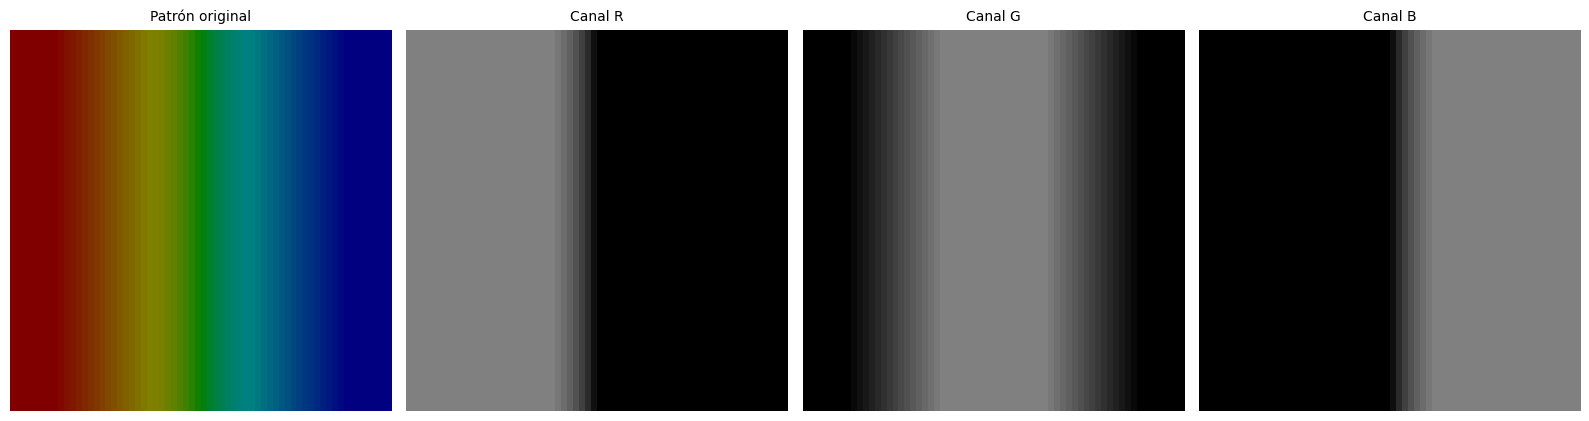

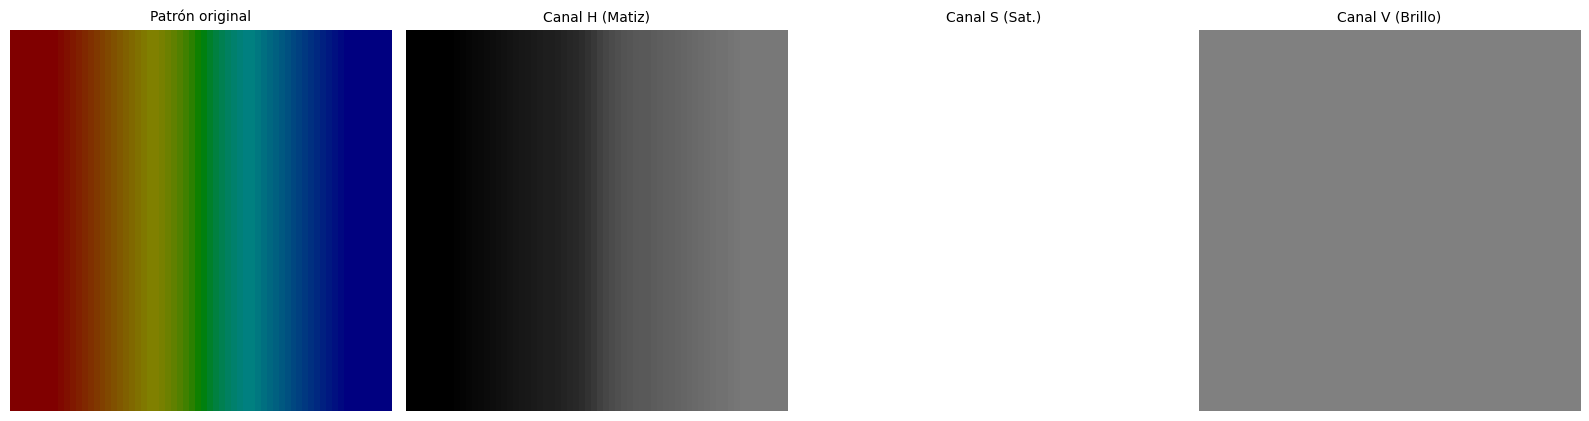

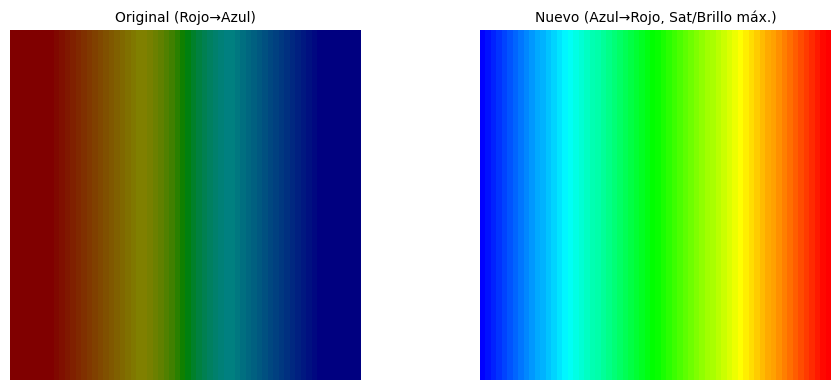

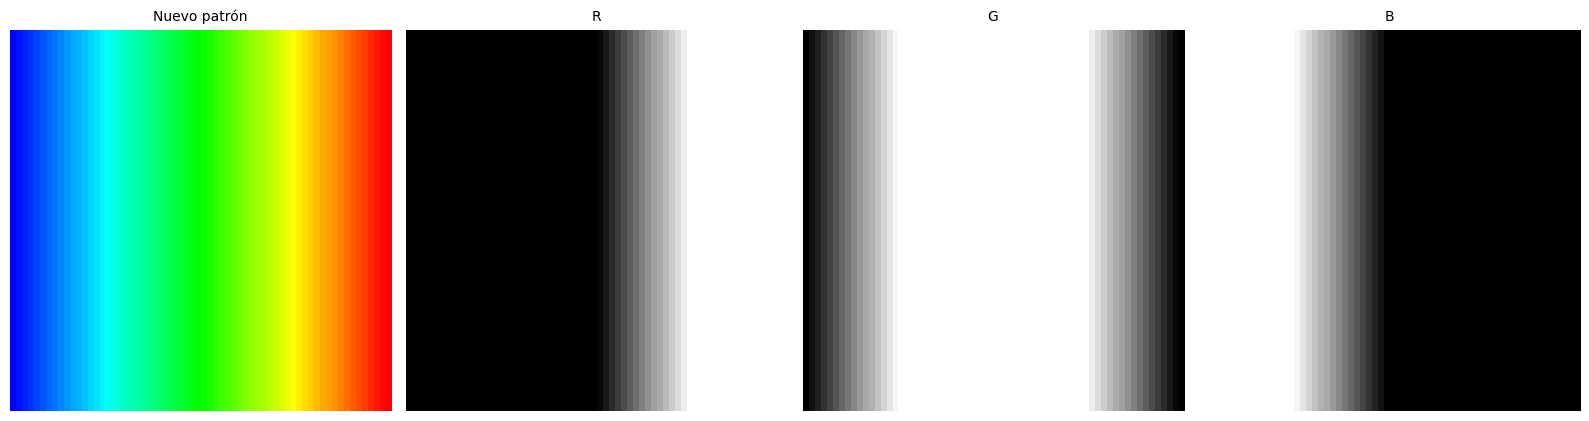

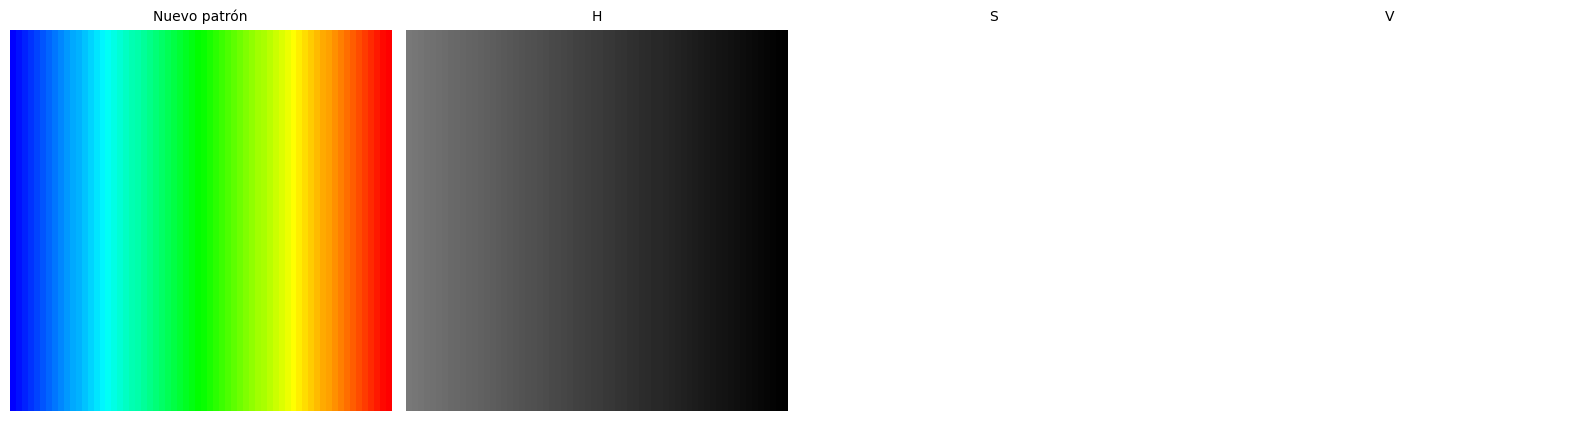

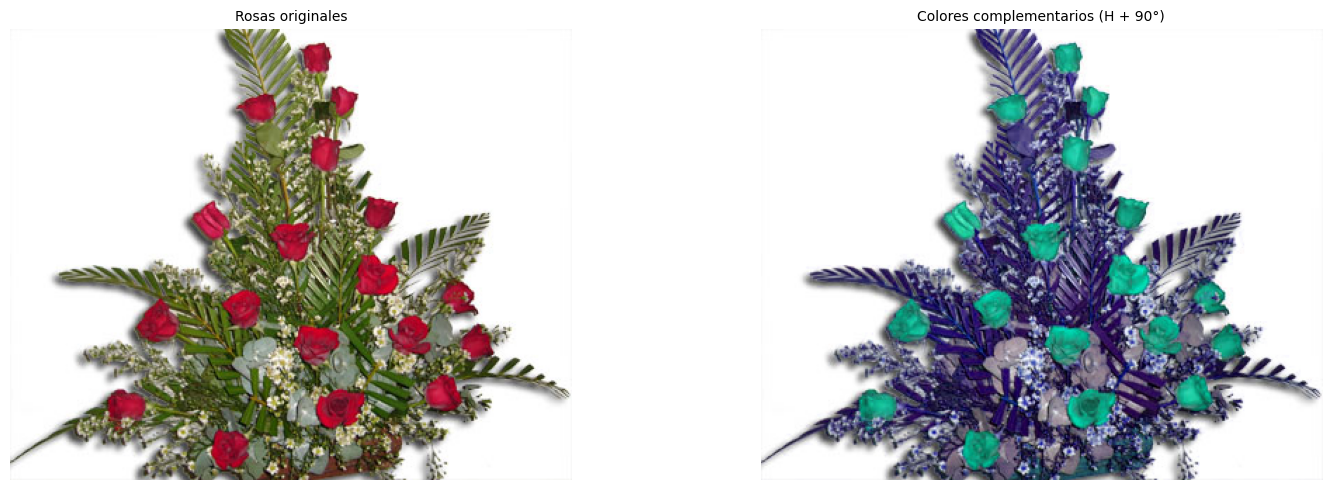

interactive(children=(IntSlider(value=31, description='Fila:', max=63), Output()), _dom_classes=('widget-inter…

In [2]:
patron = cv2.imread('patron.tif')
rosas  = cv2.imread('rosas.jpg')

# ── 1.1 Canales RGB y HSV del patrón ──────────────────────────────────────
if patron is not None:
    B, G, R = cv2.split(patron)
    H, S, V = cv2.split(cv2.cvtColor(patron, cv2.COLOR_BGR2HSV))
    mostrar([patron, R, G, B], ['Patrón original', 'Canal R', 'Canal G', 'Canal B'])
    mostrar([patron, H, S, V], ['Patrón original', 'Canal H (Matiz)', 'Canal S (Sat.)', 'Canal V (Brillo)'])

    # ── 1.1b Nuevo patrón: azul→rojo, S y V máximos ───────────────────────
    alto, ancho = patron.shape[:2]
    H_nuevo = np.tile(np.linspace(120, 0, ancho, dtype=np.uint8), (alto, 1))
    S_nuevo = np.full((alto, ancho), 255, dtype=np.uint8)
    V_nuevo = np.full((alto, ancho), 255, dtype=np.uint8)
    patron_nuevo = cv2.cvtColor(cv2.merge([H_nuevo, S_nuevo, V_nuevo]), cv2.COLOR_HSV2BGR)
    mostrar([patron, patron_nuevo], ['Original (Rojo→Azul)', 'Nuevo (Azul→Rojo, Sat/Brillo máx.)'], figsize=(10, 4))
    B2, G2, R2 = cv2.split(patron_nuevo)
    H2, S2, V2 = cv2.split(cv2.cvtColor(patron_nuevo, cv2.COLOR_BGR2HSV))
    mostrar([patron_nuevo, R2, G2, B2], ['Nuevo patrón', 'R', 'G', 'B'])
    mostrar([patron_nuevo, H2, S2, V2], ['Nuevo patrón', 'H', 'S', 'V'])
else:
    print('No se encontró patron.tif')

# ── 1.2 Colores complementarios (rosas.jpg) ───────────────────────────────
if rosas is not None:
    H_r, S_r, V_r = cv2.split(cv2.cvtColor(rosas, cv2.COLOR_BGR2HSV))
    H_comp = ((H_r.astype(np.int16) + 90) % 180).astype(np.uint8)
    rosas_comp = cv2.cvtColor(cv2.merge([H_comp, S_r, V_r]), cv2.COLOR_HSV2BGR)
    mostrar([rosas, rosas_comp], ['Rosas originales', 'Colores complementarios (H + 90°)'])
else:
    print('No se encontró rosas.jpg')

# ── 1.3 Perfiles de intensidad RGB y HSV interactivos ─────────────────────
if patron is not None:
    img_rgb = cv2.cvtColor(patron, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(patron, cv2.COLOR_BGR2HSV)
    max_fila = patron.shape[0] - 1

    def trazar_perfiles(fila):
        R_p, G_p, B_p = img_rgb[fila,:,0], img_rgb[fila,:,1], img_rgb[fila,:,2]
        H_p, S_p, V_p = img_hsv[fila,:,0], img_hsv[fila,:,1], img_hsv[fila,:,2]
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
        ax1.plot(R_p, 'r', label='R'); ax1.plot(G_p, 'g', label='G'); ax1.plot(B_p, 'b', label='B')
        ax1.set_title(f'Perfil RGB — Fila {fila}'); ax1.set_ylabel('Intensidad'); ax1.legend(); ax1.grid(alpha=0.3)
        ax2.plot(H_p, color='purple', label='H (0–179)'); ax2.plot(S_p, color='orange', label='S'); ax2.plot(V_p, color='black', label='V')
        ax2.set_title(f'Perfil HSV — Fila {fila}'); ax2.set_xlabel('Columna'); ax2.set_ylabel('Valor'); ax2.legend(); ax2.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

    interact(trazar_perfiles, fila=IntSlider(min=0, max=max_fila, value=max_fila//2, description='Fila:'))

### Análisis — Ejercicio 1

**Canal RGB del patrón:** el canal R decrece de izquierda a derecha (máximo en rojo puro, nulo en azul), el canal B hace lo opuesto, y el canal G permanece bajo salvo en las mezclas intermedias (cian/magenta).

**Canal HSV del patrón:** el canal H varía continuamente de 0° (rojo) a 240°/120 en OpenCV (azul), capturando la posición en la rueda cromática de forma compacta. S se mantiene alta (colores puros) y V constante (misma luminosidad en todo el patrón). Esto confirma que **H es el descriptor más compacto e independiente del brillo** para identificar colores.

**Nuevo patrón (azul→rojo, S=V=255):** al fijar S y V al máximo obtenemos los colores más saturados y brillantes posibles. El canal H ahora va de 120 a 0, invirtiendo el recorrido. Los canales R y B del nuevo patrón son simétricamente inversos a los del original, mientras G sigue el mismo comportamiento de mezcla.

**Colores complementarios:** sumar 90 unidades (en la escala 0–179 de OpenCV, equivalente a 180° en la rueda cromática) al canal H desplaza cada tono a su opuesto manteniendo exactamente la misma textura (S y V intactos). El resultado visual es una inversión cromática sin pérdida de contraste ni detalles.

---
## Ejercicio 2: Pseudocolor sobre imagen de radar/infrarrojo

La imagen `rio.jpg` está en escala de grises. El objetivo es asignar color amarillo a las zonas con acumulación de agua (río central y ramas) identificándolas por su rango de intensidad en el histograma.

In [5]:
img_rio = cv2.imread('rio.jpg', cv2.IMREAD_GRAYSCALE)

if img_rio is None:
    print('No se encontró rio.jpg')
else:
    def mostrar_pseudocolor(rango):
        bajo, alto = rango
        resultado = cv2.cvtColor(img_rio, cv2.COLOR_GRAY2BGR)
        mascara = cv2.inRange(img_rio, bajo, alto)
        resultado[mascara > 0] = [0, 255, 255]  # Amarillo en BGR
        fig, axs = plt.subplots(1, 3, figsize=(18, 6))
        axs[0].imshow(img_rio, cmap='gray'); axs[0].set_title('Original (grises)'); axs[0].axis('off')
        axs[1].hist(img_rio.ravel(), bins=256, range=[0,256], color='steelblue'); axs[1].axvspan(bajo, alto, alpha=0.3, color='yellow')
        axs[1].set_title(f'Histograma (rango seleccionado: {bajo}–{alto})'); axs[1].grid(alpha=0.3)
        axs[2].imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)); axs[2].set_title('Pseudocolor (agua = amarillo)'); axs[2].axis('off')
        plt.tight_layout(); plt.show()

    interact(mostrar_pseudocolor,
             rango=IntRangeSlider(value=[0, 60], min=0, max=255, step=1,
                                  description='Rango agua:', continuous_update=False,
                                  layout=widgets.Layout(width='500px')))

interactive(children=(IntRangeSlider(value=(0, 60), continuous_update=False, description='Rango agua:', layout…

### Análisis — Ejercicio 2

El histograma de `rio.jpg` típicamente muestra un pico en los valores bajos de intensidad correspondientes al agua (superficies lisas devuelven menos señal radar) y otro pico en valores altos para la vegetación y suelo. Ajustando el slider al rango de bajas intensidades se colorea selectivamente el agua en amarillo sin afectar el resto de la escena.

**Ventaja del pseudocolor:** permite al ojo humano distinguir regiones que en escala de grises son difíciles de separar visualmente, aprovechando la mayor sensibilidad perceptiva a diferencias de tono que a diferencias de luminosidad.

---
## Ejercicio 3: Procesamiento de imágenes en color

### 3.1 — Ecualización de histograma: RGB vs HSV vs HSI
### 3.2 — Realce mediante filtro pasa altos (acentuado)

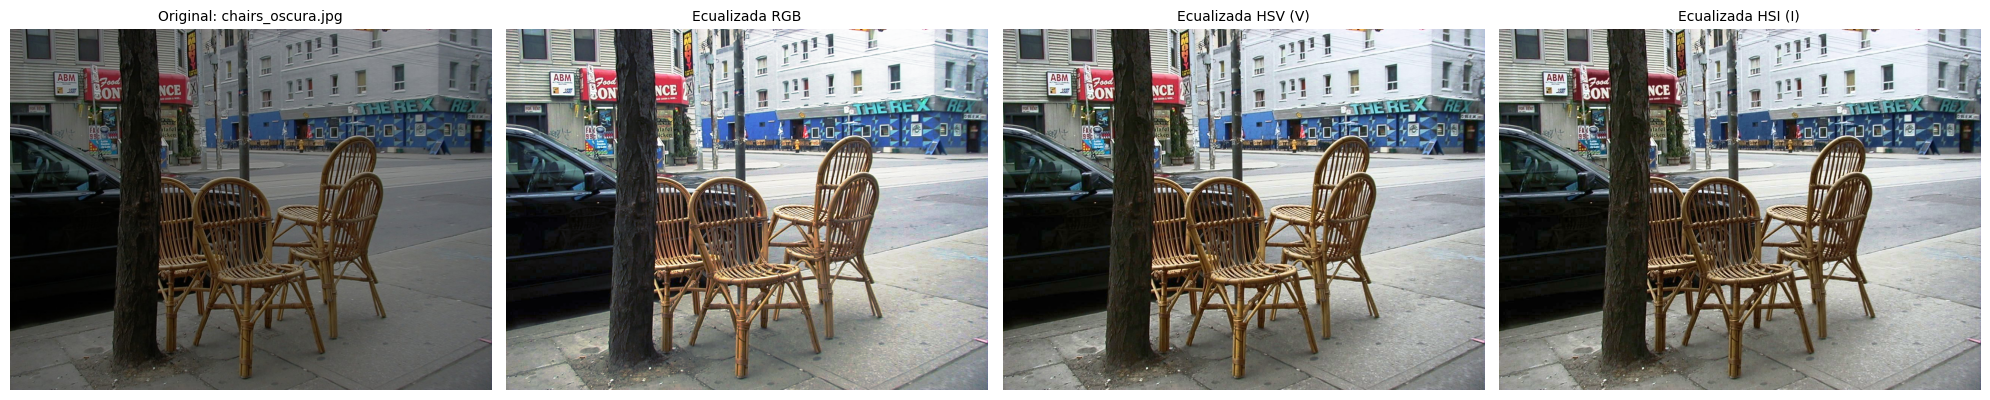

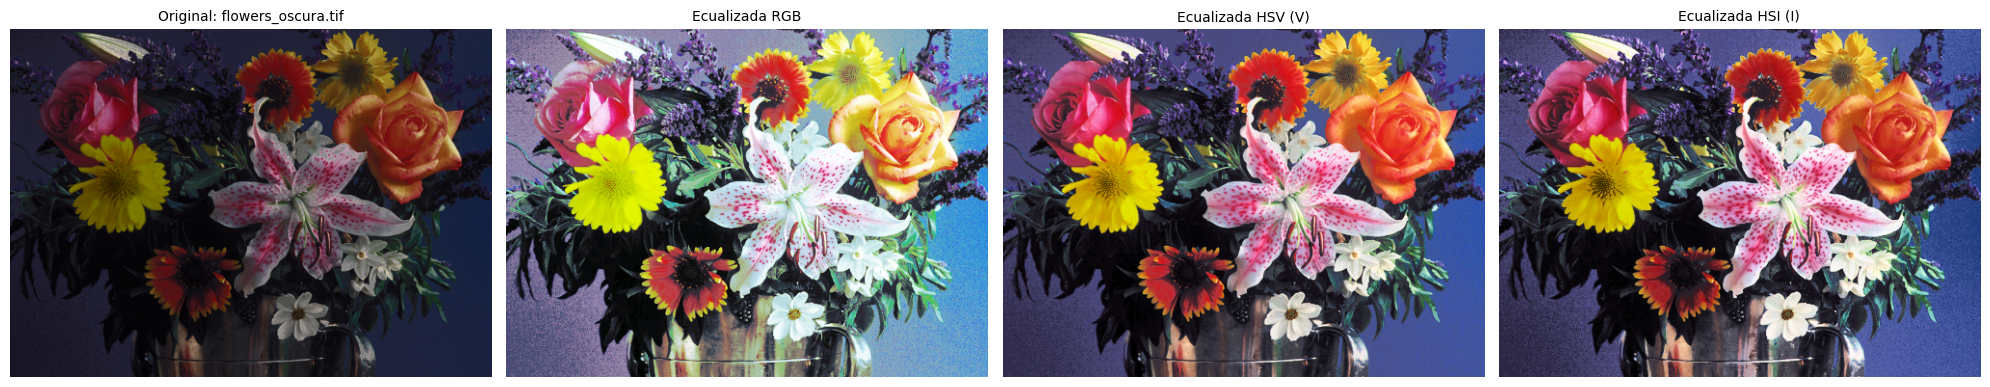

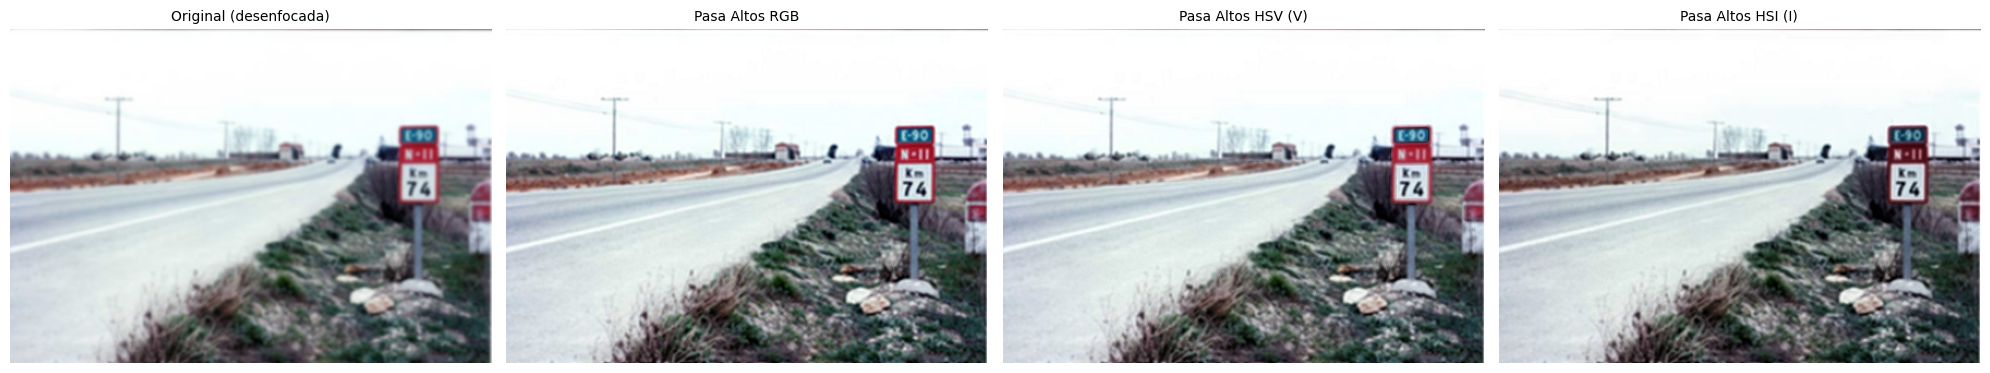

In [6]:
def reconstruir_desde_hsi(H, S, I_mod):
    """Aproximación: reemplaza el canal V por la intensidad modificada y convierte de vuelta."""
    return cv2.cvtColor(cv2.merge([H, S, I_mod]), cv2.COLOR_HSV2BGR)

kernel_pa = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32)  # Pasa altos suma 1

# ── 3.1 Ecualización ─────────────────────────────────────────────────────
for nombre in ('chairs_oscura.jpg', 'flowers_oscura.tif'):
    img = cv2.imread(nombre)
    if img is None: print(f'No se encontró {nombre}'); continue

    # RGB — plano por plano (produce artefactos de color)
    b, g, r = cv2.split(img)
    eq_rgb = cv2.merge([cv2.equalizeHist(b), cv2.equalizeHist(g), cv2.equalizeHist(r)])

    # HSV — solo canal V (preserva el tono y saturación)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    eq_hsv = cv2.cvtColor(cv2.merge([h, s, cv2.equalizeHist(v)]), cv2.COLOR_HSV2BGR)

    # HSI — solo canal I
    I = canal_I_hsi(img)
    eq_hsi = reconstruir_desde_hsi(h, s, cv2.equalizeHist(I))

    mostrar([img, eq_rgb, eq_hsv, eq_hsi],
            [f'Original: {nombre}', 'Ecualizada RGB', 'Ecualizada HSV (V)', 'Ecualizada HSI (I)'],
            figsize=(20, 5))

# ── 3.2 Realce pasa altos ─────────────────────────────────────────────────
img_camino = cv2.imread('camino.tif')
if img_camino is None:
    print('No se encontró camino.tif')
else:
    pa_rgb = cv2.filter2D(img_camino, -1, kernel_pa)

    h_c, s_c, v_c = cv2.split(cv2.cvtColor(img_camino, cv2.COLOR_BGR2HSV))
    pa_hsv = cv2.cvtColor(cv2.merge([h_c, s_c, cv2.filter2D(v_c, -1, kernel_pa)]), cv2.COLOR_HSV2BGR)

    I_c  = canal_I_hsi(img_camino)
    pa_hsi = reconstruir_desde_hsi(h_c, s_c, cv2.filter2D(I_c, -1, kernel_pa))

    mostrar([img_camino, pa_rgb, pa_hsv, pa_hsi],
            ['Original (desenfocada)', 'Pasa Altos RGB', 'Pasa Altos HSV (V)', 'Pasa Altos HSI (I)'],
            figsize=(20, 5))

### Análisis — Ejercicio 3

**Ecualización RGB (plano a plano):** al ecualizar cada canal R, G y B por separado se altera la relación entre ellos, generando artefactos de color (saturación exagerada y corrimientos de tono). El resultado se ve más brillante pero con colores artificiales.

**Ecualización HSV (canal V):** al actuar únicamente sobre el brillo se distribuye mejor la luminosidad sin tocar el tono (H) ni la saturación (S). Los colores se conservan y el resultado es visualmente más natural.

**Ecualización HSI (canal I):** produce un resultado similar al HSV pero con leve diferencia en zonas muy saturadas, ya que I es el promedio aritmético de los tres canales y no es equivalente a V. En general HSV da mejores resultados para ecualización.

**Realce pasa altos:** el filtro de suma 1 agrega los bordes detectados (diferencia con la imagen suavizada) a la propia imagen, acentuando detalles finos sin cambiar la luminosidad media. Aplicado en HSV o HSI solo al canal de brillo evita que el realce introduzca cambios de color, lo que lo hace superior al método RGB para imágenes naturales.

---
## Ejercicio 4: Segmentación basada en color


In [8]:
def segmentar(img_path, r_c, g_c, b_c, radio, h_rango, s_rango):
    img = cv2.imread(img_path)
    if img is None: print(f'No se encontró {img_path}'); return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # RGB — esfera
    dist = np.linalg.norm(img_rgb.astype(np.float32) - np.array([r_c, g_c, b_c], np.float32), axis=2)
    mask_rgb = (dist <= radio).astype(np.uint8) * 255
    seg_rgb  = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_rgb)

    # HSV — subespacio rectangular
    img_hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask_hsv = cv2.inRange(img_hsv, np.array([h_rango[0], s_rango[0], 0]),
                                    np.array([h_rango[1], s_rango[1], 255]))
    seg_hsv  = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_hsv)

    mostrar([img_rgb, mask_rgb, mask_hsv],
            ['Original', f'Máscara RGB (r={radio})', f'Máscara HSV (H:{h_rango})'])
    mostrar([img_rgb, seg_rgb, seg_hsv],
            ['Original', 'Segmentación RGB', 'Segmentación HSV'])

interact(segmentar,
         img_path=['futbol.jpg', 's01_i08_H_CM.png', 's03_i10_H_DM.png', 's05_i10_H_DM.png','s06_i13_H_LV.png','s08_i06_H_MA.png'],
         r_c=IntSlider(min=0, max=255, value=180, description='R centro'),
         g_c=IntSlider(min=0, max=255, value=130, description='G centro'),
         b_c=IntSlider(min=0, max=255, value=100, description='B centro'),
         radio=IntSlider(min=10, max=150, value=60, description='Radio esfera'),
         h_rango=IntRangeSlider(min=0, max=179, value=[0, 25], description='H rango', continuous_update=False),
         s_rango=IntRangeSlider(min=0, max=255, value=[50, 150], description='S rango', continuous_update=False))

interactive(children=(Dropdown(description='img_path', options=('futbol.jpg', 's01_i08_H_CM.png', 's03_i10_H_D…

<function __main__.segmentar(img_path, r_c, g_c, b_c, radio, h_rango, s_rango)>

## Análisis y Conclusiones - Ejercicio 4

### Comparación entre los métodos RGB y HSV

- El método **RGB (esfera)** es sencillo pero muy sensible a cambios de brillo y sombras.
- El método **HSV (rango rectangular)** es más robusto, ya que separa la tonalidad (Hue) de la saturación, logrando mejor segmentación bajo diferentes condiciones de iluminación.

**Conclusión:** El método **HSV** ofrece mejores resultados en la mayoría de los casos reales.

### ¿Es posible obtener un conjunto de valores óptimo para todas las imágenes?

**No.** Los valores óptimos dependen fuertemente de la iluminación, el color del objeto y el fondo. No existe un único conjunto de parámetros que funcione para todas las imágenes.

### ¿Es suficiente aplicar la segmentación sin pre-procesamiento?

**No.** Sin pre-procesamiento (filtro de ruido, corrección de contraste o ecualización), la segmentación genera mucho ruido, falsos positivos y bordes irregulares.

### ¿Dónde están los mayores inconvenientes?

- Variaciones de iluminación y sombras
- Colores similares entre el objeto y el fondo
- Reflexiones y brillos especulares
- Cambios en saturación por distancia o ángulo de la cámara

### Condiciones homogéneas vs heterogéneas observadas

- **Homogéneas:** Color principal del objeto, distancia cámara-objeto (en algunas tomas).
- **Heterogéneas:** Iluminación ambiente, sombras, fondo de la escena, pose del sujeto, vestimenta y accesorios.

### Consideraciones útiles para generar una buena base de datos de imágenes

- Capturar bajo distintas condiciones de iluminación (natural, artificial, fuerte y débil)
- Incluir fondos simples y complejos
- Variar ángulos y distancias de captura
- Registrar diferentes poses y orientaciones del objeto
- Incluir imágenes con y sin sombras
- Capturar distintos tonos de piel y colores del objeto
- Generar pares de imágenes (original y con pre-procesamiento) para comparación
- Documentar las condiciones de cada captura (iluminación, distancia, hora, etc.)

---
## Ejercicio 5: Trabajos de aplicación

### 5.1 


In [12]:
img_fut = cv2.imread('futbol.jpg')

if img_fut is None:
    print('No se encontró futbol.jpg')
else:
    img_fut_hsv = cv2.cvtColor(img_fut, cv2.COLOR_BGR2HSV)
    img_fut_rgb = cv2.cvtColor(img_fut, cv2.COLOR_BGR2RGB)

    toggle = widgets.ToggleButtons(options=['Máscara', 'Segmentación'], description='Vista:', button_style='info')
    out    = widgets.Output()

    h_sl = IntRangeSlider(min=0, max=179, value=[0,179], description='H', continuous_update=False, layout=widgets.Layout(width='500px'))
    s_sl = IntRangeSlider(min=0, max=255, value=[0,255], description='S', continuous_update=False, layout=widgets.Layout(width='500px'))
    v_sl = IntRangeSlider(min=0, max=255, value=[0,255], description='V', continuous_update=False, layout=widgets.Layout(width='500px'))

    def actualizar(*args):
        mascara = cv2.inRange(img_fut_hsv,
                              np.array([h_sl.value[0], s_sl.value[0], v_sl.value[0]]),
                              np.array([h_sl.value[1], s_sl.value[1], v_sl.value[1]]))
        vista = cv2.cvtColor(mascara, cv2.COLOR_GRAY2RGB) if toggle.value == 'Máscara' \
                else cv2.bitwise_and(img_fut_rgb, img_fut_rgb, mask=mascara)
        with out:
            clear_output(wait=True)
            fig, axs = plt.subplots(1, 2, figsize=(14, 5))
            axs[0].imshow(img_fut_rgb); axs[0].set_title('Original'); axs[0].axis('off')
            axs[1].imshow(vista); axs[1].set_title(toggle.value); axs[1].axis('off')
            plt.tight_layout(); plt.show()

    for w in (h_sl, s_sl, v_sl, toggle): w.observe(actualizar, names='value')
    display(widgets.VBox([toggle, h_sl, s_sl, v_sl, out]))
    actualizar()

### 5.2 — Detección de deforestación en imagen satelital

In [13]:
img_def = cv2.imread('Deforestacion.png')

if img_def is None:
    print('No se encontró Deforestacion.png')
else:
    img_def_rgb = cv2.cvtColor(img_def, cv2.COLOR_BGR2RGB)
    img_def_hsv = cv2.cvtColor(img_def, cv2.COLOR_BGR2HSV)

    # Auto-detección del recuadro blanco (zona de trabajo)
    gris = cv2.cvtColor(img_def, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gris, 200, 255, cv2.THRESH_BINARY)
    contornos, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mascara_roi = np.zeros_like(gris)
    if contornos:
        x, y, w, h = cv2.boundingRect(max(contornos, key=cv2.contourArea))
        if w > 100 and h > 100:
            cv2.rectangle(mascara_roi, (x+5, y+5), (x+w-10, y+h-10), 255, -1)
        else:
            mascara_roi[:] = 255
    else:
        mascara_roi[:] = 255

    pix_roi = cv2.countNonZero(mascara_roi)
    has_por_pixel = 24500.0 / pix_roi if pix_roi > 0 else 0

    def detectar_deforestacion(h_rango, s_rango, v_rango):
        lower = np.array([h_rango[0], s_rango[0], v_rango[0]])
        upper = np.array([h_rango[1], s_rango[1], v_rango[1]])
        mask_color = cv2.inRange(img_def_hsv, lower, upper)
        mask_final = cv2.bitwise_and(mask_color, mask_color, mask=mascara_roi)

        resultado = img_def_rgb.copy()
        resultado[mask_final > 0] = [255, 0, 0]  # Rojo = zona deforestada

        pix_def  = cv2.countNonZero(mask_final)
        has_def  = pix_def * has_por_pixel
        has_mont = 24500.0 - has_def

        fig, axs = plt.subplots(1, 3, figsize=(18, 6))
        axs[0].imshow(img_def_rgb); axs[0].set_title('Imagen original'); axs[0].axis('off')
        axs[1].imshow(mask_final, cmap='gray'); axs[1].set_title('Máscara deforestación'); axs[1].axis('off')
        axs[2].imshow(resultado)
        axs[2].set_title(f'Deforestado: {has_def:,.0f} has\nMonte: {has_mont:,.0f} has', fontweight='bold')
        axs[2].axis('off')
        plt.tight_layout(); plt.show()

    interact(detectar_deforestacion,
             h_rango=IntRangeSlider(min=0, max=179, value=[10, 60], description='H', continuous_update=False, layout=widgets.Layout(width='500px')),
             s_rango=IntRangeSlider(min=0, max=255, value=[10,150], description='S', continuous_update=False, layout=widgets.Layout(width='500px')),
             v_rango=IntRangeSlider(min=0, max=255, value=[60,220], description='V', continuous_update=False, layout=widgets.Layout(width='500px')))

interactive(children=(IntRangeSlider(value=(10, 60), continuous_update=False, description='H', layout=Layout(w…

### Análisis — Ejercicio 5

**5.1 Segmentador:** el enfoque con ipywidgets y `inRange` en HSV permite ajustar los rangos de H, S y V de forma independiente y ver el resultado inmediatamente. El toggle entre máscara y segmentación facilita evaluar si la máscara captura correctamente la región de interés sin incluir falsos positivos.

**5.2 Deforestación:** el canal H del espacio HSV diferencia bien el marrón/ocre de las zonas deforestadas (H ≈ 10–30, baja saturación) del verde de la vegetación (H ≈ 35–80). La auto-detección del recuadro blanco permite restringir el análisis a la zona delimitada por el experto, ignorando el entorno de la imagen. El área se calcula escalando la cantidad de píxeles detectados usando la referencia de 24.500 ha para el total del recuadro.